# Before you trust a number

GitHub's public activity fell by a third overnight in May 2025 and never
recovered. This notebook works out whether users left.

They did not. Nothing happened to users.

The order below is the order I would work in on the job: run the standard
checks first, and when they come back clean, keep going — because clean
standard checks do not mean the data is good, they mean the data is
well-formed.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

import charts
import figures
from data import WINDOW_END, WINDOW_START, connect, events

# Drawing lives in src/figures.py so the same code renders the light figures
# below and the dark ones on the published page. The queries stay here, because
# the queries are the argument.
theme = charts.use("light")
con = connect()
frames = figures.load(con)   # registers the `ev` and `accounts` views too
print(f"analysis window: {WINDOW_START} to {WINDOW_END}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

analysis window: 2025-04-21 to 2025-09-05


## 1. What one row is

GitHub publishes every public action anyone takes — a push, a pull request, a
comment, a star — as one row. Someone, something they did, what they did it
to, and when.

This is the same shape as product events anywhere else: `user_id`,
`event_name`, `properties`, `timestamp`.

In [2]:
con.sql("""
    SELECT event_type, created_at, actor_login, repo_name, action
    FROM ev WHERE event_type = 'PullRequestEvent' LIMIT 5
""").df()

,event_type,created_at,actor_login,repo_name,action
0,PullRequestEvent,2025-04-21 00:00:01+00:00,lukem570,lukem570/split-gui,closed
1,PullRequestEvent,2025-04-21 00:00:01+00:00,Yenesey2001,4GeeksAcademy/DronFarm1.1,closed
2,PullRequestEvent,2025-04-21 00:00:02+00:00,dependabot[bot],kasiopeiya/cdk-data-streaming-samples,opened
3,PullRequestEvent,2025-04-21 00:00:02+00:00,direwolf-github,direwolf-github/my-app-dd6b8cae,opened
4,PullRequestEvent,2025-04-21 00:00:03+00:00,aws-aemilia-fra,aws-aemilia-fra/Github-PR-Commit-Integration-T...,closed


## 2. The standard checklist

Duplicates, missing values, broken types. This is where cleaning usually
starts and, too often, stops.

In [3]:
# Counting distinct ids needs the whole column in memory, so this runs on one
# month rather than all 138 days. The point it makes does not change with scale.
events(con, "events_2025-06-*.parquet", view="june")

con.sql("""
    SELECT count(*)                                   AS rows,
           count(*) - count(DISTINCT event_id)        AS duplicate_rows,
           sum(CASE WHEN actor_id   IS NULL THEN 1 ELSE 0 END) AS missing_actor,
           sum(CASE WHEN repo_id    IS NULL THEN 1 ELSE 0 END) AS missing_repo,
           sum(CASE WHEN created_at IS NULL THEN 1 ELSE 0 END) AS missing_time
    FROM june
""").df().T.rename(columns={0: "value"})

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,value
rows,107911604.0
duplicate_rows,47.0
missing_actor,0.0
missing_repo,0.0
missing_time,0.0


**47 duplicated rows in 108 million, and nothing missing.**

Some columns are mostly NULL — `pr_merged` is empty on 93% of rows — but that
is structure, not damage: most events are not pull requests, so the column has
nothing to say about them. A NULL that means "not applicable" is not a gap.

So the checklist passes. If the work stopped here, the conclusion would be
"the data is clean" — and that conclusion would be wrong.

## 3. The number that started this

Events per day, across the window.

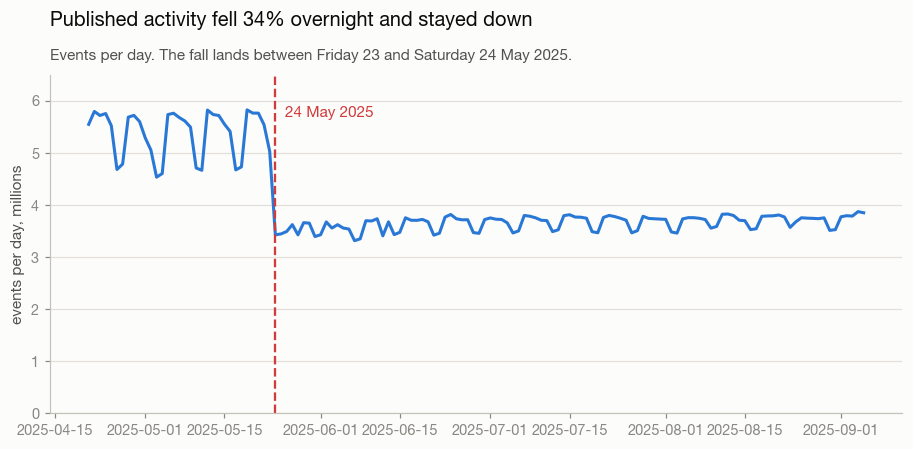

In [4]:
figures.daily_events(frames["daily"], theme);

A 34% fall between a Friday and a Saturday that never comes back.

The obvious story is that users left. Three checks say otherwise.

## 4. Check one — did everything fall together?

When people change how they work, the change shows up somewhere in
particular. Reviews slow down, or stars dry up, or issues pile up. It does not
hit every single thing by the same amount.

In [5]:
con.sql("""
    WITH per_day AS (
      SELECT created_at::DATE AS d, event_type, count(*) AS n
      FROM ev WHERE created_at::DATE BETWEEN DATE '2025-05-10' AND DATE '2025-06-07'
      GROUP BY 1, 2
    )
    SELECT event_type,
           round(avg(CASE WHEN d <  DATE '2025-05-24' THEN n END)) AS before,
           round(avg(CASE WHEN d >= DATE '2025-05-24' THEN n END)) AS after,
           round(100.0 * (avg(CASE WHEN d >= DATE '2025-05-24' THEN n END)
                        / avg(CASE WHEN d <  DATE '2025-05-24' THEN n END) - 1), 1) AS change_pct
    FROM per_day GROUP BY 1
    HAVING avg(CASE WHEN d < DATE '2025-05-24' THEN n END) > 20000
    ORDER BY before DESC
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,event_type,before,after,change_pct
0,PushEvent,3391197.0,2215052.0,-34.7
1,CreateEvent,648476.0,434837.0,-32.9
2,PullRequestEvent,359648.0,247630.0,-31.1
3,IssueCommentEvent,214183.0,142472.0,-33.5
4,WatchEvent,196663.0,127079.0,-35.4
5,DeleteEvent,129898.0,87230.0,-32.8
6,PullRequestReviewEvent,116643.0,75033.0,-35.7
7,IssuesEvent,86492.0,55636.0,-35.7
8,PullRequestReviewCommentEvent,78918.0,51182.0,-35.1
9,ForkEvent,48928.0,30868.0,-36.9


Pushes −34.7%, pull requests −31.1%, stars −35.4%, issues −35.7%, comments
−33.5%.

Everything, by the same third. That is not how people behave. That is how a
pipe behaves.

## 5. Check two — is there a ceiling?

If something is capping the flow, the cap will be visible as a hard limit on
the busiest hours, and it will bite hardest exactly when there is most to cut.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

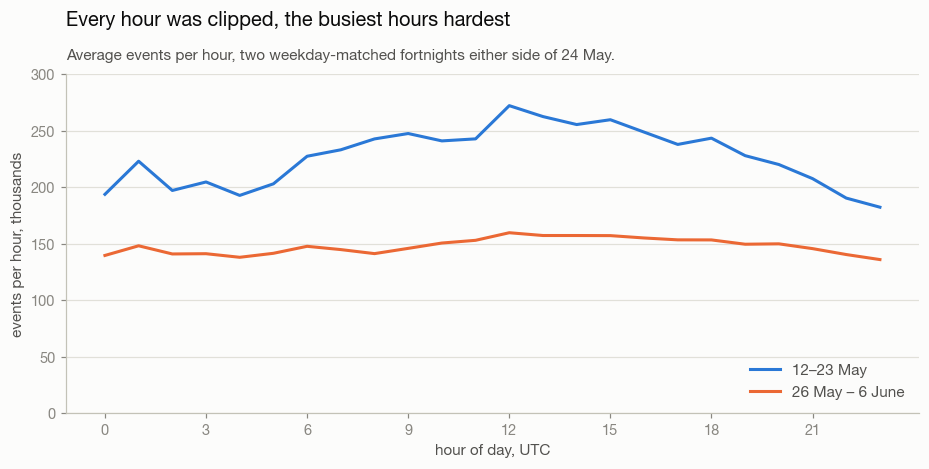

In [6]:
hourly = frames["hourly"]
con.sql("""
    WITH h AS (
      SELECT created_at::DATE AS d, hour(created_at) AS hour, count(*) AS n
      FROM ev GROUP BY 1, 2
    )
    SELECT hour,
      avg(CASE WHEN d BETWEEN DATE '2025-05-12' AND DATE '2025-05-23' THEN n END) AS before,
      avg(CASE WHEN d BETWEEN DATE '2025-05-26' AND DATE '2025-06-06' THEN n END) AS after
    FROM h GROUP BY hour ORDER BY hour
""").df().head(4)

figures.hourly_ceiling(hourly, theme);

The line does not drop — it flattens against a lid.

And the clipping is uneven: 58% of events survive at the busiest hour, 75% at
the quietest. Peak-to-trough was 1.49× before and 1.17× after.

**This matters beyond the drop itself.** The data after the cap is not a
smaller copy of the data before it. Busy hours are under-represented, and with
them the busiest users. Anyone measuring "when is our peak load" or "how
active are our heaviest users" on this data gets a wrong answer — with no
warning that anything is off.

In [7]:
kept = (100 * hourly.after / hourly.before).round(1)
print(f"kept at the busiest hour: {kept[hourly.before.idxmax()]}%")
print(f"kept at the quietest hour: {kept[hourly.before.idxmin()]}%")
print(f"peak-to-trough before: {hourly.before.max() / hourly.before.min():.2f}x")
print(f"peak-to-trough after:  {hourly.after.max() / hourly.after.min():.2f}x")

kept at the busiest hour: 58.7%
kept at the quietest hour: 74.6%
peak-to-trough before: 1.49x
peak-to-trough after:  1.17x


## 6. Now the rows that did arrive — who sent them?

The rows are well-formed. That does not make them people.

Three rules, each catching what the one before it misses. An account-day is
assigned to the first rule it matches, so the shares add up to the whole.

1. **Declared** — the login ends in `[bot]`. GitHub Apps always act through
   such an account. This is the rule everyone uses.
2. **Round the clock** — active in 20 or more of the day's 24 hours, with at
   least 200 events. People sleep.
3. **One target, one action** — 200+ events, all of one type, into at most two
   repositories. The shape of a script pushing to its own repository on a
   timer.

The floor of 200 is far above where people stop: the median account produces 2
events a day and the 99.9th percentile produces 166.

In [8]:
mix = frames["mix"]
con.sql("""
    SELECT kind, sum(events) AS events,
           round(100.0 * sum(events) / sum(sum(events)) OVER (), 1) AS pct
    FROM accounts
    GROUP BY 1 ORDER BY events DESC
""").df()

,kind,events,pct
0,person,350764201.0,62.5
1,declared bot,141901328.0,25.3
2,round the clock,58411147.0,10.4
3,"one target, one action",9763049.0,1.7


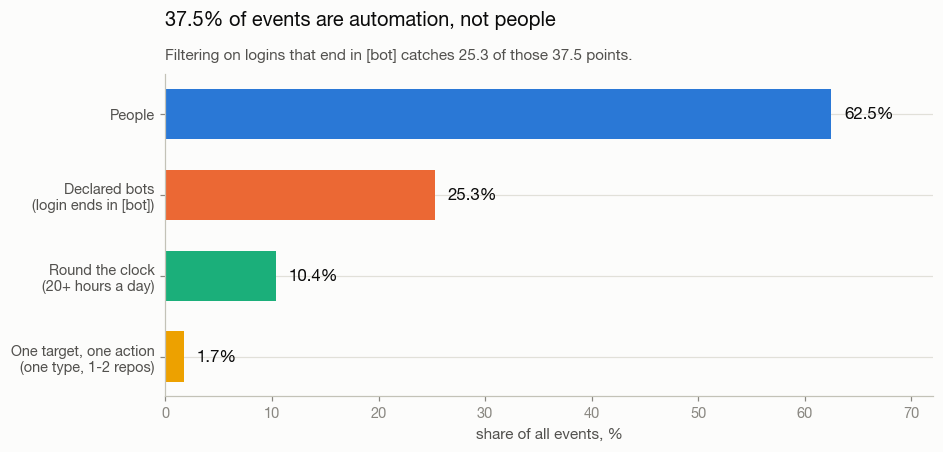

In [9]:
figures.composition(mix, theme);

**The standard rule finds two thirds of the problem.** Filtering on `[bot]`
removes 25.3% of events. The real figure is 37.5%. The missing 12.2 points are
ordinary user accounts with a script behind them, and GitHub does not mark
them, because from GitHub's side there is nothing to mark.

Here is what that looks like up close.

In [10]:
con.sql("""
    SELECT login, sum(events) AS events, count(*) AS days,
           round(avg(repos)) AS repos, round(avg(hours)) AS hours_per_day
    FROM accounts
    WHERE kind = 'round the clock'
    GROUP BY 1 ORDER BY events DESC LIMIT 5
""").df()

,login,events,days,repos,hours_per_day
0,Copilot,2048147.0,247,1432.0,24.0
1,freefastconnect,1797320.0,114,1.0,23.0
2,direwolf-github,1592166.0,137,2643.0,24.0
3,SoliSpirit,1336980.0,135,2.0,24.0
4,adi224foreverg,1146503.0,114,1.0,24.0


`freefastconnect` pushed to **one** repository 1.8 million times across 114
active days, 23 hours a day. That is about eleven pushes a minute, without a
break.

## 7. Is the rule real, or did I invent it?

A rule that flags whatever you point it at is worthless. So: can anything
outside my own data confirm it?

The GitHub API cannot. Asked about these accounts it answers
`"type": "User"` — which is correct, they are user accounts.

But GitHub removes accounts that abuse the platform. If the rules find real
automation, the accounts they flag should disappear more often than the ones
they do not. I sampled 150 accounts per rule and asked the API whether each
still exists.

In [11]:
summary = frames["summary"]
summary.loc[figures.KINDS][["sampled", "gone", "gone_pct", "lo", "hi"]].round(1)

,sampled,gone,gone_pct,lo,hi
kind,,,,,
person,150,4,2.7,1.0,6.7
declared bot,150,5,3.3,1.4,7.6
round the clock,155,27,17.4,12.3,24.2
"one target, one action",155,39,25.2,19.0,32.5


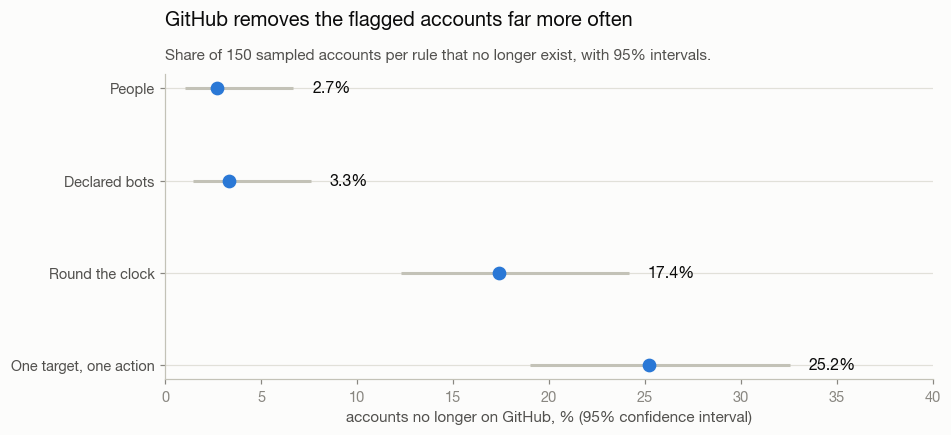

In [12]:
figures.deletion_rates(summary, theme);

In [13]:
for rule in ["round the clock", "one target, one action"]:
    a, b = summary.loc[rule], summary.loc["person"]
    odds, p = stats.fisher_exact([[a.gone, a.sampled - a.gone],
                                  [b.gone, b.sampled - b.gone]])
    print(f"{rule:24} vs people: odds ratio {odds:5.1f}, p = {p:.1e}")

round the clock          vs people: odds ratio   7.7, p = 1.4e-05
one target, one action   vs people: odds ratio  12.3, p = 3.9e-09


This is corroboration, not proof. GitHub removes accounts for reasons that
have nothing to do with automation, and plenty of legitimate automation is
never removed. What it rules out is that the rules fire at random.

One lead worth writing down so nobody chases it twice: the number of public
repositories an account owns is almost useless here. Round-the-clock accounts
hold a median of 8 against 4 for people, which looks like something until you
notice it is one of two comparisons at p = 0.035 — and the other comparison,
one-target accounts at a median of 5, comes back at p = 0.55.

## 8. Two smaller traps, both fatal to per-user metrics

In [14]:
con.sql("""
    SELECT 'logins used by more than one account' AS trap, count(*) AS n
    FROM (SELECT login FROM accounts GROUP BY 1
          HAVING count(DISTINCT actor_id) > 1)
    UNION ALL
    SELECT 'accounts that changed their login', count(*)
    FROM (SELECT actor_id FROM accounts GROUP BY 1
          HAVING count(DISTINCT login) > 1)
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,trap,n
0,logins used by more than one account,2289
1,accounts that changed their login,119857


Two different accounts both posted as `Copilot`, one with 1.44M events and one
with 0.60M. Join on the login and they become a single user. Meanwhile 119,857
accounts renamed inside the window, one of them 43 times — keyed on the login,
each of those looks like one user leaving and another arriving.

`actor_id` never changes. Everything here keys on it.

## What I would take to the team

**Check the pipe before you explain the number.** A 34% drop should trigger
one query — events per hour — before anyone writes a sentence about user
behaviour. The ceiling is visible in thirty seconds. Worth wiring as an alert:
any daily metric moving more than 15% gets the completeness check
automatically.

**Report automation next to the metric, not instead of it.** Stripping bots
out entirely is the wrong call — on a developer platform the automation *is*
part of the product. What is wrong is letting it sit inside "active users"
unlabelled. Split every headline metric into people and automation and watch
the ratio.

**Do not trust `[bot]` alone.** It finds two thirds. Re-run the behavioural
rules every quarter, because automation keeps changing shape — the biggest
undeclared account here, `Copilot`, did not exist two years ago.

**Key on the id, never the display name.**

### How I would know it worked

Take the ten metrics on the main dashboard. For each, compute the automation
share and the completeness check across the last two years. The test is not
whether the numbers move — they will. It is **how many past decisions would
have gone differently.** That is the number to put in front of the team.